# 05 — Extracción de Características

Se convierte cada radiografía preprocesada en un vector de características numéricas.
El resultado es un CSV donde cada fila es una imagen y las columnas son las features
extraídas.

**Pipeline por imagen:**
```
imagen → preprocesamiento (BF + CLAHE) → extracción → fila del CSV
```

| Grupo | Qué captura | Features |
|---|---|---|
| Intensidad global | brillo, variabilidad, rango dinámico, desorden | 4 |
| Intensidad regional | lo mismo en 6 zonas anatómicas (ver `04`) | 24 |
| GLCM | relación entre píxeles vecinos — textura del tejido | 10 |
| LBP | micropatrones locales — bordes finos y transiciones | 26 |
| HOG | gradientes orientados — forma y estructura | 1764 |
| **Total** | | **1828** |

In [1]:
import os
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import entropy as scipy_entropy
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

In [2]:
DATA_ROOT  = os.path.join(os.path.expanduser('~'), '.cache', 'kagglehub',
                          'datasets', 'usmanshams', 'tbx-11', 'versions', '1', 'TBX11K')
IMG_SIZE   = (256, 256)
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')
OUTPUT_CSV = os.path.join(os.path.dirname(os.getcwd()), 'features_tbx11k.csv')

# Si se corre desde la raíz del proyecto
if not os.path.exists(os.path.dirname(OUTPUT_CSV)):
    OUTPUT_CSV = 'features_tbx11k.csv'

records = []
imgs_dir = Path(DATA_ROOT) / 'imgs'
for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        if f.suffix.lower() in VALID_EXTS:
            records.append({'image_path': str(f), 'class_name': class_name, 'label': label})

df_base = pd.DataFrame(records)
print(f'Imágenes: {len(df_base)}')
print(f'CSV destino: {OUTPUT_CSV}')

Imágenes: 8400
CSV destino: c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\features_tbx11k.csv


---
## 1. Preprocesamiento

La misma cadena de los notebooks anteriores.
Todas las características se calculan sobre la imagen preprocesada.

In [3]:
def preprocess(path: str) -> np.ndarray | None:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=80, sigmaSpace=80)
    clahe = cv2.createCLAHE(clipLimit=40, tileGridSize=(8, 8))
    return clahe.apply(img)

---
## 2. Extractores de características

In [4]:
# --- Intensidad global ---
# mean: brillo promedio de toda la imagen
# std: variabilidad — más heterogeneidad = tejido más irregular
# contrast: diferencia entre el píxel más brillante y el más oscuro
# entropy: desorden del histograma — lesiones TB aumentan la heterogeneidad

def feat_intensity_global(img: np.ndarray) -> dict:
    h      = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    h_norm = h / (h.sum() + 1e-9)
    return {
        'mean':     float(np.mean(img)),
        'std':      float(np.std(img)),
        'contrast': float(int(img.max()) - int(img.min())),
        'entropy':  float(scipy_entropy(h_norm + 1e-9)),
    }

In [5]:
# --- Intensidad regional ---
# Las mismas 4 métricas en 6 zonas anatómicas.
# Se incluyen porque el análisis en 04_Analisis_Regional muestra que
# SI y SD tienen intensidades distintas en tb vs health.
# Sin separar por zona, esa señal se diluye en la media global.

REGIONS = {
    'SI': (0,   0,   128, 86),
    'SD': (128, 0,   128, 86),
    'MI': (0,   86,  128, 85),
    'MD': (128, 86,  128, 85),
    'II': (0,   171, 128, 85),
    'ID': (128, 171, 128, 85),
}

def feat_intensity_regional(img: np.ndarray) -> dict:
    feats = {}
    for name, (x, y, w, h) in REGIONS.items():
        roi    = img[y:y+h, x:x+w]
        hr     = cv2.calcHist([roi], [0], None, [256], [0, 256]).flatten()
        hr_norm = hr / (hr.sum() + 1e-9)
        feats[f'{name}_mean']     = float(np.mean(roi))
        feats[f'{name}_std']      = float(np.std(roi))
        feats[f'{name}_contrast'] = float(int(roi.max()) - int(roi.min()))
        feats[f'{name}_entropy']  = float(scipy_entropy(hr_norm + 1e-9))
    return feats

In [6]:
# --- GLCM ---
# Mide la relación entre píxeles vecinos a 4 ángulos (0°, 45°, 90°, 135°).
# Promediando los 4 ángulos el descriptor es invariante a la orientación
# de las estructuras anatómicas.
#
# Se usan 64 niveles de gris (img // 4) por eficiencia y robustez al ruido.
# Para cada propiedad se guarda mean y std de los 4 ángulos:
#   mean → textura promedio en todas las direcciones
#   std  → anisotropía (cuánto varía la textura según la dirección)

GLCM_PROPS  = ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

def feat_glcm(img: np.ndarray) -> dict:
    img64 = (img // 4).astype(np.uint8)
    glcm  = graycomatrix(
        img64, distances=[1], angles=GLCM_ANGLES,
        levels=64, symmetric=True, normed=True
    )
    feats = {}
    for prop in GLCM_PROPS:
        vals = graycoprops(glcm, prop).flatten()
        feats[f'glcm_{prop}_mean'] = float(np.mean(vals))
        feats[f'glcm_{prop}_std']  = float(np.std(vals))
    return feats

In [7]:
# --- LBP ---
# Compara cada píxel con sus 24 vecinos en un círculo de radio 3.
# method='uniform': solo patrones con ≤ 2 transiciones 0→1.
# Descarta patrones ruidosos y conserva los estructuralmente significativos
# (bordes, esquinas, manchas). El histograma se normaliza para ser
# independiente del tamaño de la imagen.

LBP_P    = 24
LBP_R    = 3
LBP_BINS = LBP_P + 2  # 26 bins

def feat_lbp(img: np.ndarray) -> dict:
    lbp_img = local_binary_pattern(img, P=LBP_P, R=LBP_R, method='uniform')
    hist, _ = np.histogram(lbp_img.ravel(), bins=LBP_BINS, range=(0, LBP_BINS), density=True)
    return {f'lbp_{i}': float(v) for i, v in enumerate(hist)}

In [8]:
# --- HOG ---
# Celdas de 32×32 píxeles (64 celdas sobre 256×256).
# pixels_per_cell=(32,32) en lugar del estándar (16,16):
#   con 16×16 → 8100 features (problemático con solo 8400 muestras)
#   con 32×32 → 1764 features (balance entre detalle y manejabilidad)
# Bloques 2×2 con normalización L2-Hys para robustez ante cambios de contraste.

HOG_ORIENTATIONS    = 9
HOG_PIXELS_PER_CELL = (32, 32)
HOG_CELLS_PER_BLOCK = (2, 2)

def feat_hog(img: np.ndarray) -> dict:
    fd = hog(
        img,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True
    )
    return {f'hog_{i}': float(v) for i, v in enumerate(fd)}

---
## 3. Verificación de los extractores

Antes de procesar las 8400 imágenes se verifica que cada extractor produce
el número correcto de features.

In [9]:
samples = {c: df_base[df_base['class_name'] == c].iloc[0]['image_path'] for c in LABEL_MAP}

for class_name, path in samples.items():
    img = preprocess(path)
    assert img is not None
    assert img.shape == IMG_SIZE

    g  = feat_glcm(img)
    l  = feat_lbp(img)
    h  = feat_hog(img)
    gi = feat_intensity_global(img)
    ri = feat_intensity_regional(img)

    total = len(g) + len(l) + len(h) + len(gi) + len(ri)
    print(f'{class_name:>6} | global={len(gi)}  regional={len(ri)}  GLCM={len(g)}  LBP={len(l)}  HOG={len(h)}  TOTAL={total}')

print()
print('Esperado: global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828')

health | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828
  sick | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828
    tb | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828

Esperado: global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828


---
## 4. Extracción masiva

Se procesan las 8400 imágenes.

In [10]:
def extract_all(image_path: str, label: int, class_name: str) -> dict | None:
    img = preprocess(image_path)
    if img is None:
        return None
    row = {'image_path': image_path, 'class_name': class_name, 'label': label}
    row.update(feat_intensity_global(img))
    row.update(feat_intensity_regional(img))
    row.update(feat_glcm(img))
    row.update(feat_lbp(img))
    row.update(feat_hog(img))
    return row

In [11]:
USE_SAMPLE  = False
SAMPLE_SIZE = 50

if USE_SAMPLE:
    df_proc = (
        df_base
        .groupby('label', group_keys=False)
        .apply(lambda x: x.sample(min(SAMPLE_SIZE, len(x)), random_state=42))
        .reset_index(drop=True)
    )
    print(f'Modo muestra: {len(df_proc)} imágenes')
else:
    df_proc = df_base.copy()
    print(f'Dataset completo: {len(df_proc)} imágenes')

rows, errors = [], []

for _, row in tqdm(df_proc.iterrows(), total=len(df_proc), desc='Extrayendo'):
    result = extract_all(row['image_path'], row['label'], row['class_name'])
    if result:
        rows.append(result)
    else:
        errors.append(row['image_path'])

features_df = pd.DataFrame(rows)
print(f'\nProcesadas : {len(features_df)}')
print(f'Errores    : {len(errors)}')
print(f'Shape      : {features_df.shape}')

Dataset completo: 8400 imágenes


Extrayendo: 100%|██████████| 8400/8400 [04:36<00:00, 30.36it/s]



Procesadas : 8400
Errores    : 0
Shape      : (8400, 1831)


---
## 5. Verificación de calidad del DataFrame

In [12]:
meta_cols = ['image_path', 'class_name', 'label']
feat_cols = [c for c in features_df.columns if c not in meta_cols]

print(f'Filas    : {len(features_df)}')
print(f'Features : {len(feat_cols)}')
print()
print('Distribución de clases:')
print(features_df['class_name'].value_counts())
print()

nulls = features_df[feat_cols].isnull().sum()
infs  = np.isinf(features_df[feat_cols].values).sum()
print(f'Valores nulos    : {nulls.sum()}')
print(f'Valores infinitos: {infs}')

grupos = {
    'Intensidad global'  : [c for c in feat_cols if c in ['mean','std','contrast','entropy']],
    'Intensidad regional': [c for c in feat_cols if any(c.startswith(r) for r in REGIONS)],
    'GLCM'               : [c for c in feat_cols if c.startswith('glcm_')],
    'LBP'                : [c for c in feat_cols if c.startswith('lbp_')],
    'HOG'                : [c for c in feat_cols if c.startswith('hog_')],
}
print()
print('Features por grupo:')
for nombre, cols in grupos.items():
    print(f'  {nombre:22}: {len(cols):>5}')
print(f'  {"TOTAL":22}: {sum(len(v) for v in grupos.values()):>5}')

Filas    : 8400
Features : 1828

Distribución de clases:
class_name
health    3800
sick      3800
tb         800
Name: count, dtype: int64

Valores nulos    : 0
Valores infinitos: 0

Features por grupo:
  Intensidad global     :     4
  Intensidad regional   :    24
  GLCM                  :    10
  LBP                   :    26
  HOG                   :  1764
  TOTAL                 :  1828


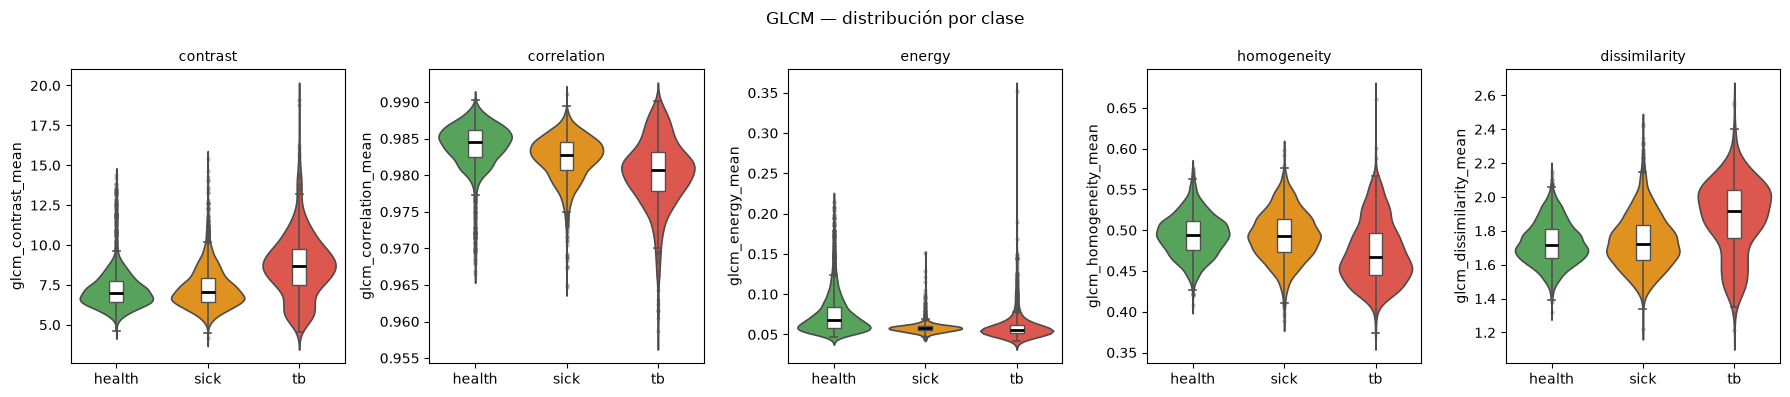

In [13]:
# Distribución GLCM por clase — verificación visual de discriminatividad

PALETTE = {'health': '#4CAF50', 'sick': '#FF9800', 'tb': '#F44336'}
glcm_mean_cols = [c for c in grupos['GLCM'] if c.endswith('_mean')]

fig, axes = plt.subplots(1, len(glcm_mean_cols), figsize=(18, 4))
for ax, col in zip(axes, glcm_mean_cols):
    sns.violinplot(
        data=features_df, x='class_name', y=col,
        order=['health','sick','tb'], palette=PALETTE,
        inner=None, linewidth=1.2, ax=ax
    )
    sns.boxplot(
        data=features_df, x='class_name', y=col,
        order=['health','sick','tb'], width=0.15,
        boxprops=dict(facecolor='white', zorder=2),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
        ax=ax
    )
    ax.set_title(col.replace('glcm_','').replace('_mean',''), fontsize=10)
    ax.set_xlabel('')

plt.suptitle('GLCM — distribución por clase', fontsize=12)
plt.tight_layout()
plt.show()

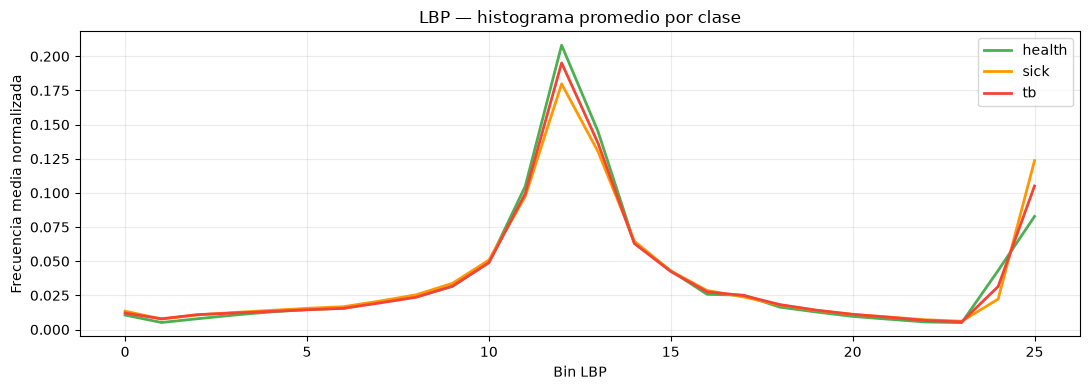

In [14]:
# Histograma LBP promedio por clase

plt.figure(figsize=(11, 4))
for class_name, color in PALETTE.items():
    mean_hist = features_df[features_df['class_name'] == class_name][grupos['LBP']].mean().values
    plt.plot(mean_hist, color=color, label=class_name, linewidth=2)

plt.xlabel('Bin LBP')
plt.ylabel('Frecuencia media normalizada')
plt.title('LBP — histograma promedio por clase')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## 6. Exportar a CSV

Se guarda en la raíz del proyecto. Este CSV es la entrada para el notebook de modelos.

In [15]:
features_df = features_df[meta_cols + feat_cols]
features_df.to_csv(OUTPUT_CSV, index=False)

print(f'Guardado : {OUTPUT_CSV}')
print(f'Shape    : {features_df.shape}')
print(f'Tamaño   : {os.path.getsize(OUTPUT_CSV) / 1024 / 1024:.1f} MB')

Guardado : c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\features_tbx11k.csv
Shape    : (8400, 1831)
Tamaño   : 288.6 MB
